In [1]:
#!/usr/bin/env python3
"""
---------------------------------------------------------------
Erstellt eine Tabelle mittlerer Muskelaktivierungen für beliebig
viele Trainingsläufe (Pickle-Logs).  
Ergebnis:  mean_activations_by_run.csv
           Zeilen = Trainingsnamen 
           Spalten = 26 Muskeln in XML-Reihenfolge
"""

# ------------------------- KONFIG -------------------------------------
TRAINING_RUNS = {
    # "Label in Tabelle" : "Pfad/zur/action_log.pickle"
    "Baseline"   : "simulators/reg_mobl_arms_index_pointing_negative_zero/evaluate/action_log.pickle",
    "LayerNorm"  : "simulators/reg_mobl_arms_index_pointing_layer_norm/evaluate/action_log.pickle",
    "Dropout0.1"   : "simulators/reg_mobl_arms_index_pointing_dropout_one/evaluate/action_log.pickle",
    "Dropout0.2"   : "simulators/reg_mobl_arms_index_pointing_dropout_two/evaluate/action_log.pickle",
    "Dropout0.3"   : "simulators/reg_mobl_arms_index_pointing_dropout_three/evaluate/action_log.pickle",
    "Dropout0.4"   : "simulators/reg_mobl_arms_index_pointing_dropout_four/evaluate/action_log.pickle",
    "Dropout0.5"   : "simulators/reg_mobl_arms_index_pointing_dropout_five/evaluate/action_log.pickle",
    "Reg1e-4"  : "simulators/reg_mobl_arms_index_pointing_negative_four_l_one/evaluate/action_log.pickle",
    "Reg1e-5"  : "simulators/reg_mobl_arms_index_pointing_negative_five_l_one/evaluate/action_log.pickle",
    "Reg1e-6"  : "simulators/reg_mobl_arms_index_pointing_negative_six_l_one/evaluate/action_log.pickle",
    "Reg1e-7"  : "simulators/reg_mobl_arms_index_pointing_negative_seven_l_one/evaluate/action_log.pickle",
    "Reg1e-8"  : "simulators/reg_mobl_arms_index_pointing_negative_eight_l_one/evaluate/action_log.pickle",
    "Reg1e-9"  : "simulators/reg_mobl_arms_index_pointing_negative_nine_l_one/evaluate/action_log.pickle",



    
    # weitere Runs hier ergänzen ...
}

OUT_CSV = "mean_activations_by_run.csv"    # Ergebnisdatei
# ----------------------------------------------------------------------

import os, pickle, numpy as np, pandas as pd

# Reihenfolge der 26 Muskeln aus bm_model.xml
MUSCLE_NAMES = [
    "DELT1","DELT2","DELT3","SUPSP","INFSP","SUBSC","TMIN","TMAJ",
    "PECM1","PECM2","PECM3","LAT1","LAT2","LAT3","CORB","TRIlong",
    "TRIlat","TRImed","ANC","SUP","BIClong","BICshort","BRA","BRD",
    "PT","PQ",
]

# Aktivierungs-Dynamik (aus dynprm="0.01 0.04 …")
TAU_ACT, TAU_DEACT, A0 = 0.010, 0.040, 0.0

# ----------------------------------------------------------------------
def excitation_to_activation(u: np.ndarray, dt: float,
                             tau_act=TAU_ACT, tau_deact=TAU_DEACT,
                             a0=A0) -> np.ndarray:
    """Low-Pass-Filter: Excitation u → Activation a."""
    a = np.empty_like(u, dtype=float)
    a[0] = a0
    for t in range(1, len(u)):
        tau = tau_act if u[t] > a[t-1] else tau_deact
        a[t] = a[t-1] + (u[t] - a[t-1]) * dt / tau
    return a

def peak_for_pickle(path: str) -> np.ndarray:
    """Gibt 26-D-Vektor mittlerer Aktivierungen über alle Episoden zurück."""
    with open(path, "rb") as f:
        log = pickle.load(f)
    sum_sq = np.zeros(26)    # Summe der Quadrate
    total_frames = 0    
    peak_vals = np.zeros(26)
    means_accum, count_frames = np.zeros(26), 0
    for ep in log.values():
        u = np.clip(np.asarray(ep["action"], dtype=float), 0.0, 1.0)  # (T, 26)
        dt = float(np.round(ep["timestep"][1] - ep["timestep"][0], 10))
        a = np.vstack([excitation_to_activation(u[:, m], dt)
                       for m in range(26)]).T
        means_accum += a.sum(axis=0)
        count_frames += a.shape[0]
        peak_vals = np.maximum(peak_vals, a.max(axis=0))
        sum_sq += (a ** 2).sum(axis=0)
        total_frames += a.shape[0]
    mean_sq = sum_sq / total_frames          # mean(a²)
    #return np.sqrt(mean_sq)       
    return means_accum / count_frames
    #return peak_vals

# ----------------------------- MAIN -----------------------------------
rows = {}
for tag, path in TRAINING_RUNS.items():
    if not os.path.isfile(path):
        print(f"⚠️  Pickle nicht gefunden: {path}")
        continue
    rows[tag] = peak_for_pickle(path)
    print(f"✔  {tag}: mean berechnet")

df = pd.DataFrame.from_dict(rows, orient="index", columns=MUSCLE_NAMES)
df.to_csv(OUT_CSV)
print(f"\nGesamt-Tabelle gespeichert → {OUT_CSV}")
print(df.head())                            # kurzer Preview


✔  Baseline: mean berechnet
✔  LayerNorm: mean berechnet
✔  Dropout0.1: mean berechnet
✔  Dropout0.2: mean berechnet
✔  Dropout0.3: mean berechnet
✔  Dropout0.4: mean berechnet
✔  Dropout0.5: mean berechnet
✔  Reg1e-4: mean berechnet
✔  Reg1e-5: mean berechnet
✔  Reg1e-6: mean berechnet
✔  Reg1e-7: mean berechnet
✔  Reg1e-8: mean berechnet
✔  Reg1e-9: mean berechnet

Gesamt-Tabelle gespeichert → mean_activations_by_run.csv
               DELT1     DELT2     DELT3     SUPSP     INFSP     SUBSC  \
Baseline    0.339844  0.496620  0.309601  0.477566  0.335394  0.738542   
LayerNorm   0.527311  0.419110  0.362988  0.476727  0.252118  0.706424   
Dropout0.1  0.222831  0.578929  0.366214  0.526837  0.305325  0.678353   
Dropout0.2  0.371112  0.549738  0.526262  0.477157  0.124444  0.486727   
Dropout0.3  0.422327  0.461396  0.533071  0.504724  0.249405  0.727301   

                TMIN      TMAJ     PECM1     PECM2  ...    TRIlat    TRImed  \
Baseline    0.303525  0.430879  0.644781  0.54015

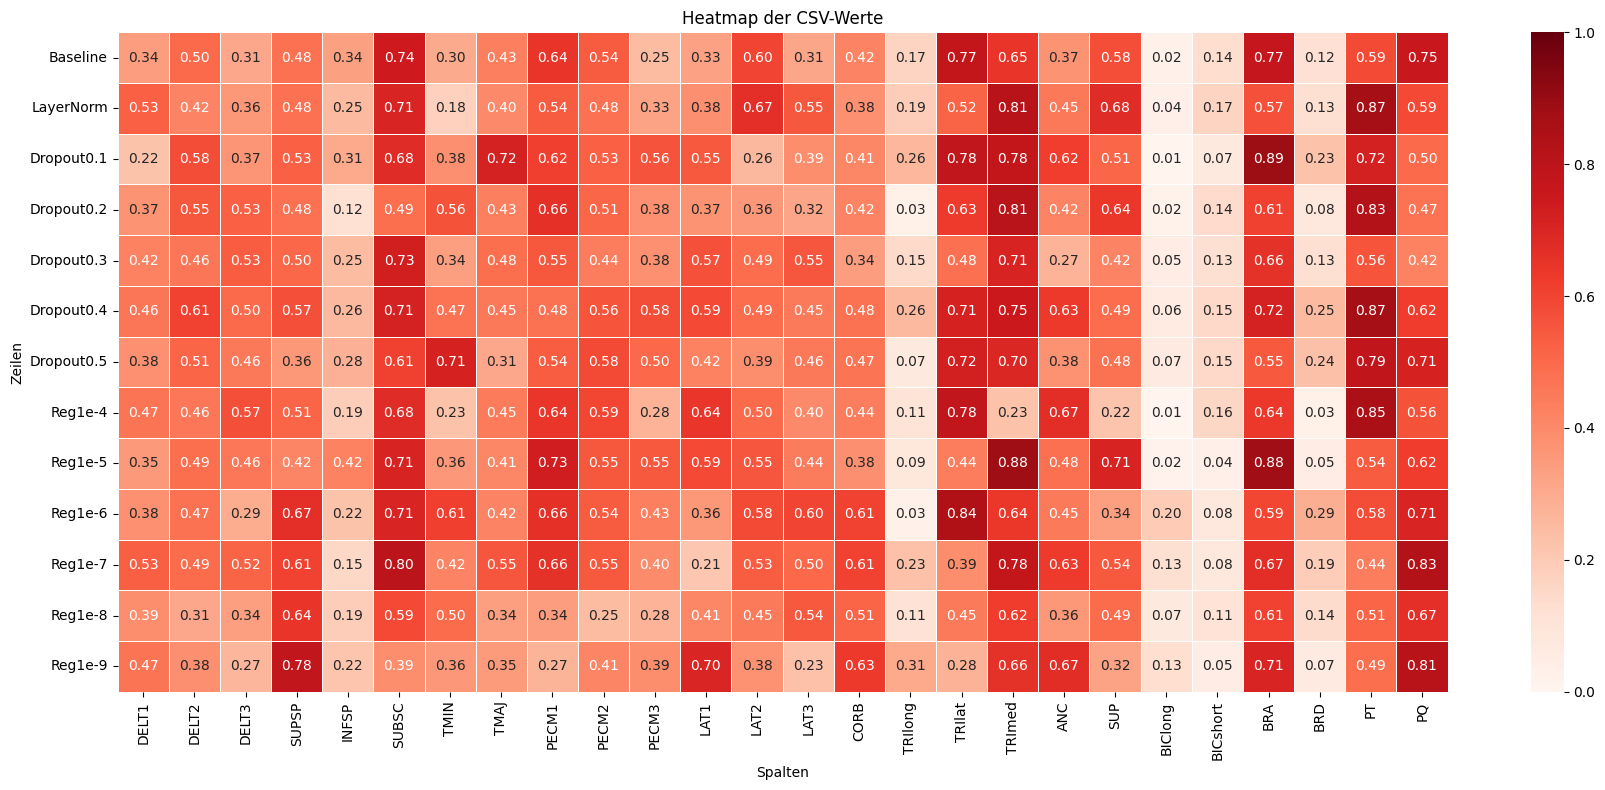

In [2]:
#### import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# CSV einlesen
df = pd.read_csv("mean_activations_by_run.csv", index_col=0)

# Sicherstellen, dass alle Werte numerisch sind
df = df.apply(pd.to_numeric, errors="coerce")
df = df.fillna(0)  # oder falls lieber leer lassen: df = df.fillna("")

# Heatmap zeichnen
plt.figure(figsize=(18, 8))
sns.heatmap(df, 
            annot=True,        # Werte anzeigen
            fmt=".2f",         # Format: zwei Nachkommastellen
            cmap="Reds",       # Farbschema
            vmin=0, vmax=1,    # Wertebereich
            linewidths=0.5,    # Gitterlinien
            cbar=True)         # Farbskala anzeigen

plt.title("Heatmap der CSV-Werte")
plt.xlabel("Spalten")
plt.ylabel("Zeilen")
plt.tight_layout()
plt.show()

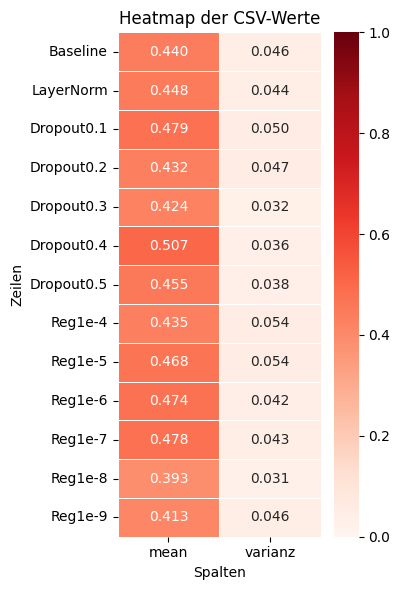

In [3]:
df = pd.read_csv('mean_activations_by_run.csv', index_col=0)
df = df.apply(pd.to_numeric, errors="coerce")

# Zeilenweiser Mittelwert und Varianz berechnen
result = pd.DataFrame({
    'mean': df.mean(axis=1),
    'varianz': df.var(axis=1)
})
plt.figure(figsize=(4, 6))
sns.heatmap(result, 
            annot=True,        # Werte anzeigen
            fmt=".3f",         # Format: zwei Nachkommastellen
            cmap="Reds",       # Farbschema
            vmin=0, vmax=1,    # Wertebereich
            linewidths=0.5,    # Gitterlinien
            cbar=True)         # Farbskala anzeigen

plt.title("Heatmap der CSV-Werte")
plt.xlabel("Spalten")
plt.ylabel("Zeilen")
plt.tight_layout()
plt.show()

# Ergebnis anzeigen oder speichern
